<a href="https://colab.research.google.com/github/Rex-Kartik/Machine-Learning/blob/main/image_Captioning_gen_ai_from_scracct/Image_reading_model_training_from_scract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Model : {device}")

Model : cuda


In [3]:
transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [4]:
training_dataset = torchvision.datasets.CIFAR10(
    root = "/content/drive/MyDrive/Colab Notebooks/Data",
    train = True,
    download= True,
    transform = transformation
)

100%|██████████| 170M/170M [56:36<00:00, 50.2kB/s]


In [5]:
testing_dataset = torchvision.datasets.CIFAR10(
    root = "/content/drive/MyDrive/Colab Notebooks/Data",
    train = False,
    download = True,
    transform = transformation
)

In [6]:
training_loader = torch.utils.data.DataLoader(
    training_dataset,
    batch_size = 64,
    shuffle = True,
    num_workers = 3
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [7]:
testing_loader = torch.utils.data.DataLoader(
    testing_dataset,
    batch_size = 64,
    shuffle = False,
    num_workers = 2
)

In [8]:
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

In [9]:
images, labels = next(iter(training_loader))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [10]:
grid = torchvision.utils.make_grid(images[:8])
grid = grid.permute(1, 2, 0)

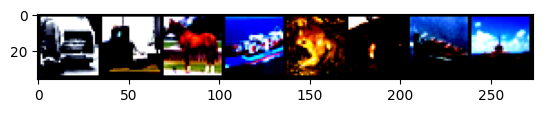

['truck', 'truck', 'horse', 'ship', 'frog', 'deer', 'ship', 'ship']


In [11]:
plt.imshow(grid)
plt.show()
print([classes[label.item()] for label in labels[:8]])

In [14]:
class TinyCNN(nn.Module):
  def __init__(self):
    super(TinyCNN, self).__init__()
    self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1)
    self.conv3 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, padding = 1)
    self.pool = nn.MaxPool2d(2,2)
    self.fc1 = nn.Linear(2048, 512)
    self.fc2 = nn.Linear(512, 64)
    self.fc3 = nn.Linear(64, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = self.pool(F.relu(self.conv3(x)))
    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [15]:
model = TinyCNN()

In [18]:
dummy_input = torch.randn(4, 3, 32, 32)
output = model(dummy_input)
print(output.shape)

torch.Size([4, 10])


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr = 0.001)

In [22]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 1,175,818


In [24]:
num_epoch = 10

In [26]:
model.to(device)
for epoch in range(num_epoch):
  model.train()
  running_loss = 0.0
  for images, labels in training_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  avg_loss = running_loss / len(training_loader)
  print(f"Epoch {epoch+1}/{num_epoch}, Loss: {avg_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/10, Loss: 1.3849
Epoch 2/10, Loss: 0.9241
Epoch 3/10, Loss: 0.7246
Epoch 4/10, Loss: 0.5908
Epoch 5/10, Loss: 0.4753
Epoch 6/10, Loss: 0.3652
Epoch 7/10, Loss: 0.2797
Epoch 8/10, Loss: 0.2105
Epoch 9/10, Loss: 0.1609
Epoch 10/10, Loss: 0.1301


In [30]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for images, labels in testing_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
  accuracy = correct * 100 / total
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 76.29
